In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
RANDOM_STATE = 42   # Her çalıştırmada aynı sonucu almak için

print("Kütüphaneler yüklendi.")

Kütüphaneler yüklendi.


In [2]:
wine = load_wine()

X = wine.data            # 178 örnek x 13 özellik
y = wine.target          # sınıf etiketleri (0, 1, 2)
feature_names = wine.feature_names

# Tablo
df = pd.DataFrame(X, columns=feature_names)
df['sinif'] = pd.Series(y).map({0: 'Barolo', 1: 'Grignolino', 2: 'Barbera'})

print("Örnek sayısı   :", X.shape[0])
print("Özellik sayısı :", X.shape[1])
print("Sınıflar       :", df['sinif'].unique())
print("Eksik veri     :", df.isnull().sum().sum())

print("\nÖzellikler:")
for i, ad in enumerate(feature_names, 1):
    print(f"  {i:2d}. {ad}")

print("\nSınıf dağılımı:")
print(df['sinif'].value_counts())

df.head()

Örnek sayısı   : 178
Özellik sayısı : 13
Sınıflar       : ['Barolo' 'Grignolino' 'Barbera']
Eksik veri     : 0

Özellikler:
   1. alcohol
   2. malic_acid
   3. ash
   4. alcalinity_of_ash
   5. magnesium
   6. total_phenols
   7. flavanoids
   8. nonflavanoid_phenols
   9. proanthocyanins
  10. color_intensity
  11. hue
  12. od280/od315_of_diluted_wines
  13. proline

Sınıf dağılımı:
sinif
Grignolino    71
Barolo        59
Barbera       48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,sinif
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,Barolo
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,Barolo
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,Barolo
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,Barolo
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,Barolo


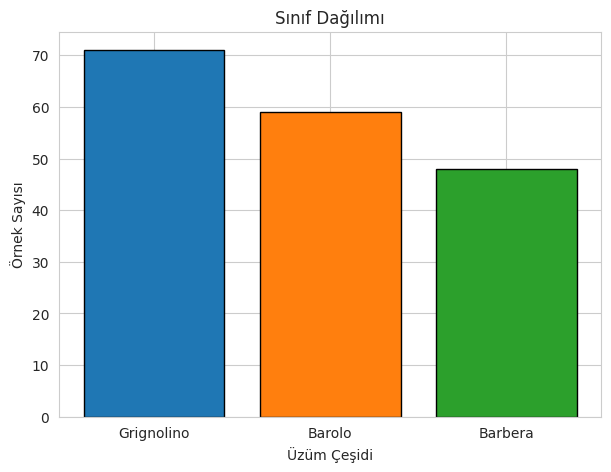

In [3]:
plt.figure(figsize=(7, 5))
counts = df['sinif'].value_counts()
plt.bar(counts.index, counts.values,
        color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black')
plt.title('Sınıf Dağılımı')
plt.xlabel('Üzüm Çeşidi')
plt.ylabel('Örnek Sayısı')
plt.savefig('sinif_dagilimi.png', dpi=150, bbox_inches='tight')
plt.show()

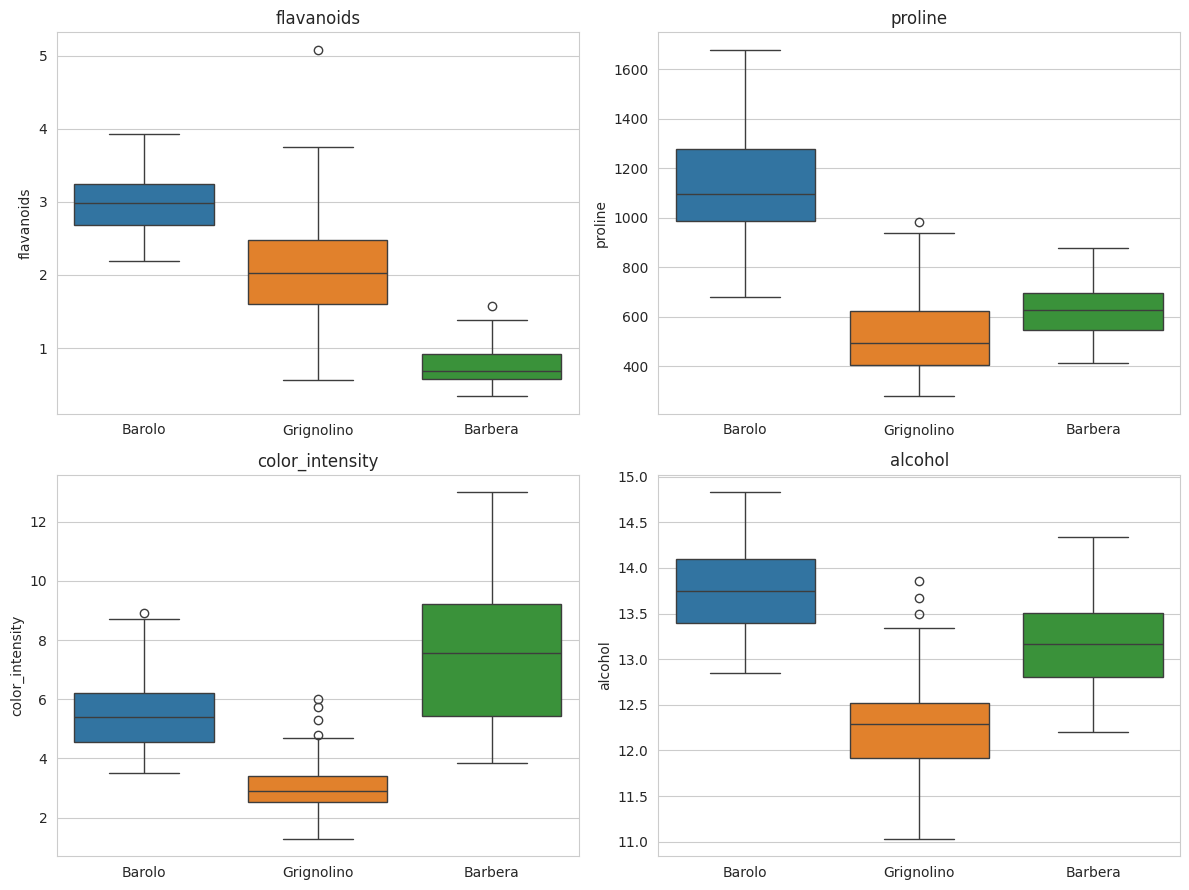

In [4]:
ozellikler = ['flavanoids', 'proline', 'color_intensity', 'alcohol']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
for i, oz in enumerate(ozellikler):
    sns.boxplot(data=df, x='sinif', y=oz, ax=axes[i],
                hue='sinif', legend=False,
                palette=['#1f77b4', '#ff7f0e', '#2ca02c'])
    axes[i].set_title(oz)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('ozellikler.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,        # %30 test, %70 eğitim
    random_state=RANDOM_STATE,
    stratify=y             # sınıf oranlarını koru
)

print("Eğitim örnekleri:", len(X_train))
print("Test örnekleri  :", len(X_test))

Eğitim örnekleri: 124
Test örnekleri  : 54


In [6]:
model = GaussianNB()
model.fit(X_train, y_train)        # öğrenme

y_pred = model.predict(X_test)     # test seti tahminleri

print("Model eğitildi ve tahminler yapıldı.")

Model eğitildi ve tahminler yapıldı.


Doğruluk (Accuracy): 100.00%

              precision    recall  f1-score   support

      Barolo      1.000     1.000     1.000        18
  Grignolino      1.000     1.000     1.000        21
     Barbera      1.000     1.000     1.000        15

    accuracy                          1.000        54
   macro avg      1.000     1.000     1.000        54
weighted avg      1.000     1.000     1.000        54



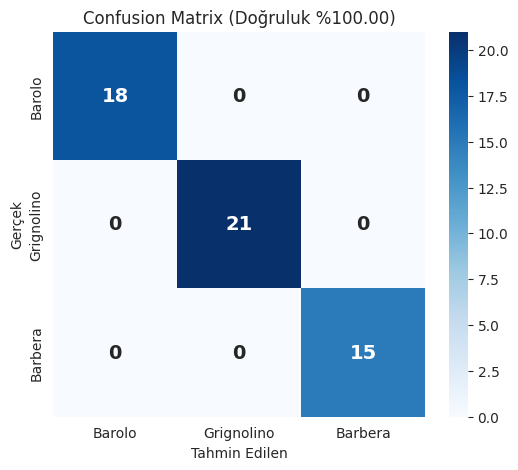


Specificity (Özgüllük):
  Barolo: 1.000
  Grignolino: 1.000
  Barbera: 1.000


In [7]:
acc = accuracy_score(y_test, y_pred)
print(f"Doğruluk (Accuracy): {acc*100:.2f}%\n")

print(classification_report(
    y_test, y_pred,
    target_names=['Barolo', 'Grignolino', 'Barbera'],
    digits=3))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Barolo', 'Grignolino', 'Barbera'],
            yticklabels=['Barolo', 'Grignolino', 'Barbera'],
            annot_kws={'size': 14, 'weight': 'bold'})
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.title(f'Confusion Matrix (Doğruluk %{acc*100:.2f})')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Specificity (her sınıf için)
print("\nSpecificity (Özgüllük):")
for i, ad in enumerate(['Barolo', 'Grignolino', 'Barbera']):
    tn = np.sum((y_test != i) & (y_pred != i))
    fp = np.sum((y_test != i) & (y_pred == i))
    print(f"  {ad}: {tn/(tn+fp):.3f}")

In [8]:
# Veriyi 5 farklı şekilde bölüp
# ortalamasını alma
skorlar = cross_val_score(GaussianNB(), X, y, cv=5)

print("Her bölünmenin doğruluğu:", [f"{s*100:.1f}%" for s in skorlar])
print(f"Ortalama doğruluk: {skorlar.mean()*100:.2f}%  (± {skorlar.std()*100:.2f}%)")

Her bölünmenin doğruluğu: ['94.4%', '97.2%', '97.2%', '94.3%', '100.0%']
Ortalama doğruluk: 96.63%  (± 2.11%)


Doğruluk (Accuracy): 96.30%

              precision    recall  f1-score   support

      Barolo      1.000     0.944     0.971        18
  Grignolino      0.952     0.952     0.952        21
     Barbera      0.938     1.000     0.968        15

    accuracy                          0.963        54
   macro avg      0.963     0.966     0.964        54
weighted avg      0.964     0.963     0.963        54



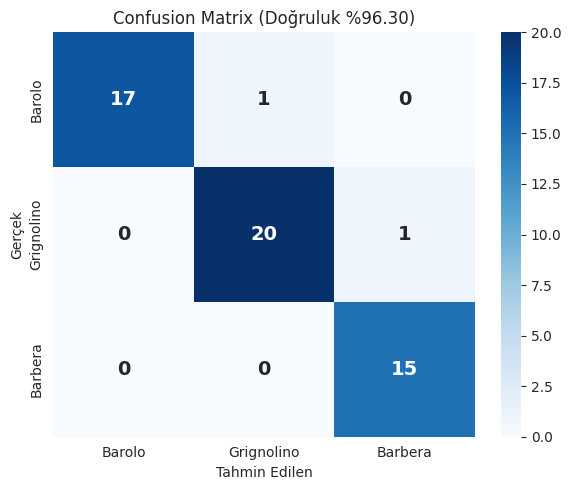

In [9]:
# Modelin yaptığı hataların tablosu
# %96.30 doğruluk veren bir bölünme
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X, y, test_size=0.30, random_state=0, stratify=y)

pred2 = GaussianNB().fit(X_tr2, y_tr2).predict(X_te2)
acc2 = accuracy_score(y_te2, pred2)
print(f"Doğruluk (Accuracy): {acc2*100:.2f}%\n")
print(classification_report(
    y_te2, pred2,
    target_names=['Barolo', 'Grignolino', 'Barbera'],
    digits=3))

cm2 = confusion_matrix(y_te2, pred2)
plt.figure(figsize=(6, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Barolo', 'Grignolino', 'Barbera'],
            yticklabels=['Barolo', 'Grignolino', 'Barbera'],
            annot_kws={'size': 14, 'weight': 'bold'})
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.title(f'Confusion Matrix (Doğruluk %{acc2*100:.2f})')
plt.tight_layout()
plt.savefig('confusion_matrix_hatali.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
cv_ort = skorlar.mean() * 100
cv_std = skorlar.std() * 100

karsilastirma = pd.DataFrame({
    'Yöntem': [
        'Gaussian Naïve Bayes (Bu Çalışma)',
        'Logistic Regression (Arafat et al., 2025)',
        'L1 Regularized LR (Arafat et al., 2025)'
    ],
    'Doğruluk': [
        f'{cv_ort:.2f}% (± {cv_std:.2f}%)',
        '98.15%',
        '93.52%'
    ]
})

print(karsilastirma.to_string(index=False))

                                   Yöntem         Doğruluk
        Gaussian Naïve Bayes (Bu Çalışma) 96.63% (± 2.11%)
Logistic Regression (Arafat et al., 2025)           98.15%
  L1 Regularized LR (Arafat et al., 2025)           93.52%
